In [ ]:
# Install SHAP
!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

df.head()

/tmp/ipykernel_6118/3022328752.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([

    ("num",
     Pipeline([
         ("imputer",SimpleImputer(strategy="median")),
         ("scaler",StandardScaler())
     ]),
     num_cols),

    ("cat",
     Pipeline([
         ("imputer",SimpleImputer(strategy="most_frequent")),
         ("encoder",OneHotEncoder(handle_unknown="ignore"))
     ]),
     cat_cols)

])

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train_processed,
    y_train
)

print("Accuracy:",
      accuracy_score(
          y_test,
          model.predict(X_test_processed)
      ))

Accuracy: 0.794180269694819


In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
3,num__TotalCharges,0.162157
1,num__tenure,0.142806
2,num__MonthlyCharges,0.137148
36,cat__Contract_Month-to-month,0.050107
18,cat__OnlineSecurity_No,0.031962
43,cat__PaymentMethod_Electronic check,0.028939
27,cat__TechSupport_No,0.026637
16,cat__InternetService_Fiber optic,0.026119
0,num__SeniorCitizen,0.019737
5,cat__gender_Male,0.018404


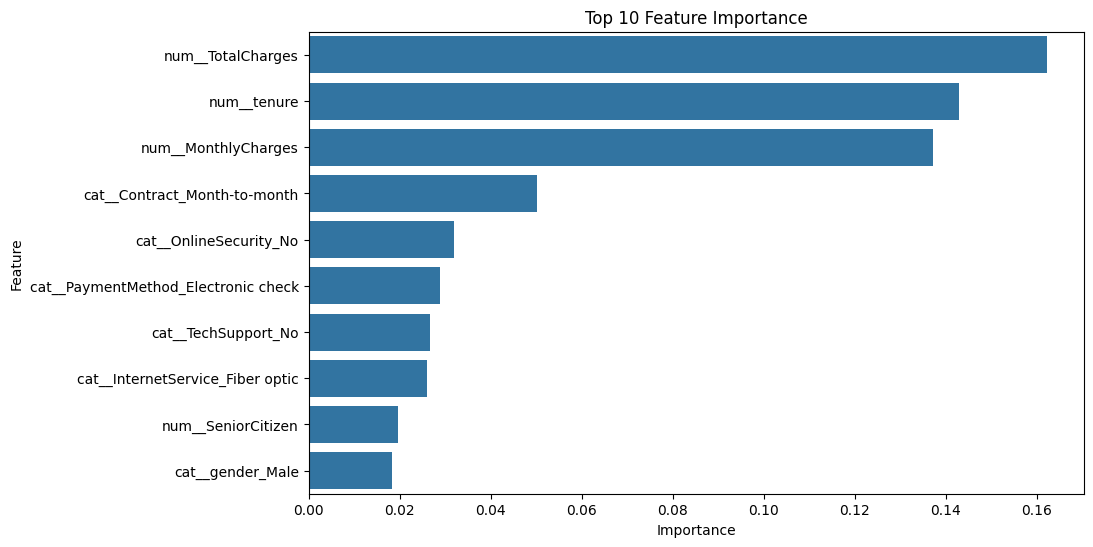

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Feature Importance")

plt.show()

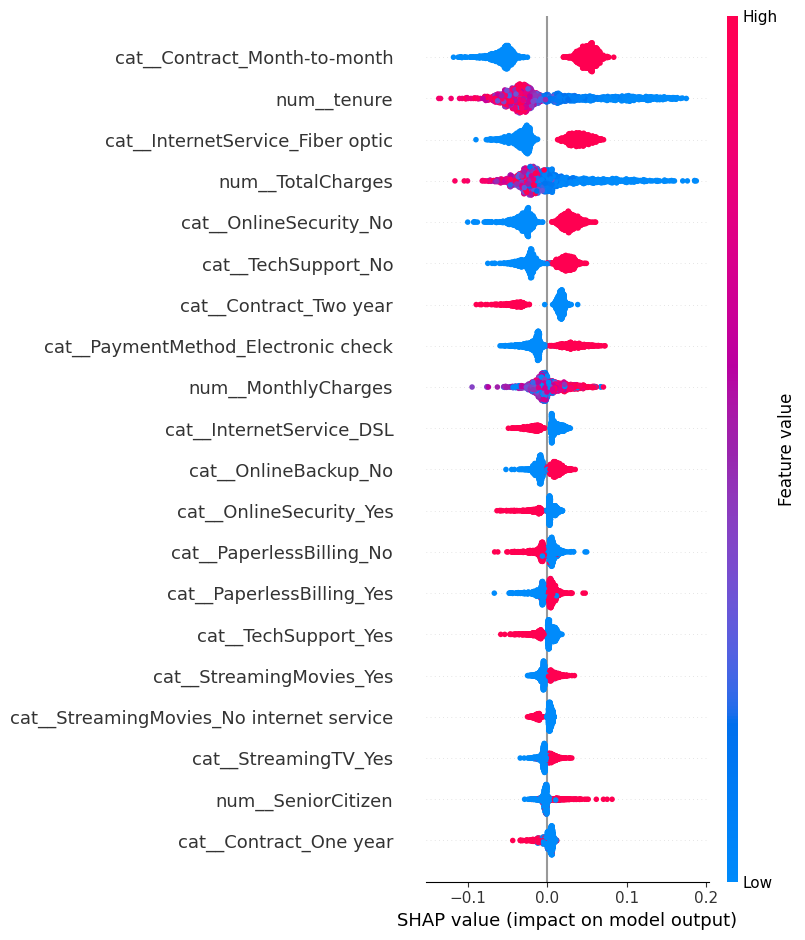

In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_test_processed
)

shap.summary_plot(

    shap_values[:,:,1],

    X_test_processed,

    feature_names=feature_names

)

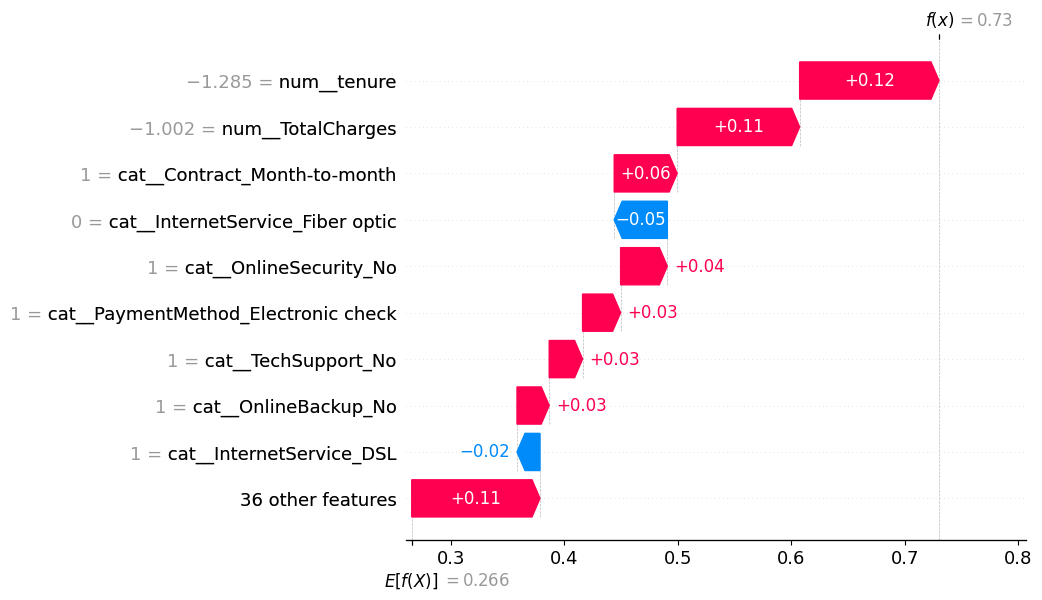

In [8]:
sample = 0

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[sample,:,1],

        base_values=explainer.expected_value[1],

        data=X_test_processed[sample],

        feature_names=feature_names

    )

)

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


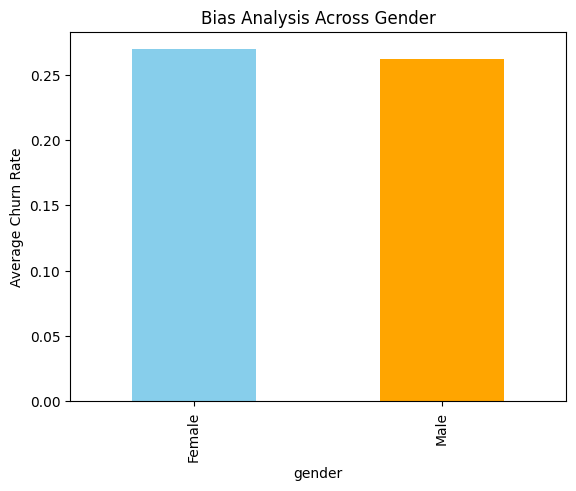

In [9]:
bias = df.groupby("gender")["Churn"].mean()

print(bias)

bias.plot(
    kind="bar",
    color=["skyblue","orange"]
)

plt.ylabel("Average Churn Rate")

plt.title("Bias Analysis Across Gender")

plt.show()

In [10]:
male = df[df["gender"]=="Male"]

female = df[df["gender"]=="Female"]

print("Male Churn Rate:",
      male["Churn"].mean())

print("Female Churn Rate:",
      female["Churn"].mean())

difference = abs(

    male["Churn"].mean()

    -

    female["Churn"].mean()

)

print("Difference:",difference)

Male Churn Rate: 0.2616033755274262
Female Churn Rate: 0.26920871559633025
Difference: 0.007605340068904065


In [11]:
recommendations = pd.DataFrame({

"Recommendation":[

"Collect balanced data",

"Remove biased features",

"Fairness-aware learning",

"Regular bias audits",

"Human review"

],

"Purpose":[

"Reduce representation bias",

"Prevent indirect discrimination",

"Improve fairness",

"Monitor bias over time",

"Verify sensitive decisions"

]

})

recommendations

,Recommendation,Purpose
0,Collect balanced data,Reduce representation bias
1,Remove biased features,Prevent indirect discrimination
2,Fairness-aware learning,Improve fairness
3,Regular bias audits,Monitor bias over time
4,Human review,Verify sensitive decisions


In [12]:
print("========== TASK 3 SUMMARY ==========\n")

print("Model Used : Random Forest")

print("Explainability : SHAP")

print("Feature Importance : Completed")

print("Local Explanation : Completed")

print("Bias Check : Gender")

print("Mitigation Suggestions : Completed")

print("\nTask 3 Successfully Completed.")

========== TASK 3 SUMMARY ==========

Model Used : Random Forest
Explainability : SHAP
Feature Importance : Completed
Local Explanation : Completed
Bias Check : Gender
Mitigation Suggestions : Completed

Task 3 Successfully Completed.
